# AI-Driven Parking-Induced Congestion Analysis System
### Bengaluru Traffic Police (BTP) & Flipkart Gridlock Hackathon 2.0

This notebook implements a solution to the operational challenge: 
**"How can AI-driven parking intelligence detect illegal parking hotspots and quantify their impact on traffic flow to enable targeted enforcement?"**

### Methodology
We formulate the **Parking Congestion Index (PCI)** to model the traffic obstruction severity of each violation:
$$PCI = W_{vehicle} \times W_{temporal} \times W_{spatial} \times W_{validation}$$

1. **Vehicle Weight ($W_{vehicle}$)**: Larger vehicles occupy more road width.
2. **Temporal Peak Weight ($W_{temporal}$)**: Violations during peak commute hours cause significantly more congestion.
3. **Spatial Junction Proximity Weight ($W_{spatial}$)**: Parking near intersections blocking turnings causes severe gridlock.
4. **Validation Weight ($W_{validation}$)**: Filters out false positives and weights pending reviews.

We then run **DBSCAN Spatial Clustering** to identify high-density hotspots, rank them by cumulative PCI, and create interactive maps with **Folium**.

## Step 1: Import Libraries

In [26]:
import pandas as pd
import numpy as np
import json
from sklearn.cluster import DBSCAN
import folium
from folium.plugins import HeatMap
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="darkgrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load and Clean Dataset (Local Directory)

In [27]:
dataset_path = 'jan to may police violation_anonymized791b166.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at '{dataset_path}'. Please verify it is in the same directory as this notebook.")

print(f"Loading dataset from {dataset_path}...")
df = pd.read_csv(dataset_path, low_memory=False)
print(f"Total raw records loaded: {len(df):,}")

# Remove invalid coordinates (outside Bangalore boundaries)
df = df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'] >= 12.7) & (df['latitude'] <= 13.2)]
df = df[(df['longitude'] >= 77.4) & (df['longitude'] <= 77.9)]
print(f"Records with valid Bengaluru coordinates: {len(df):,}")

Loading dataset from jan to may police violation_anonymized791b166.csv...
Total raw records loaded: 298,450
Records with valid Bengaluru coordinates: 298,282


## Step 3: Feature Engineering & Parking Congestion Index (PCI) Calculation

In [28]:
# Parse timestamps
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')
df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.day_name()

# 1. Vehicle Weights (Larger vehicles = higher obstruction)
vehicle_weights = {
    'SCOOTER': 1.0, 'MOTOR CYCLE': 1.0, 'MOPED': 1.0,
    'PASSENGER AUTO': 2.0, 'GOODS AUTO': 2.0,
    'CAR': 3.0, 'SUV': 3.0, 'JEEP': 3.0, 'VAN': 3.0,
    'LGV': 5.0, 'TEMPO': 5.0,
    'PRIVATE BUS': 10.0, 'BUS (BMTC/KSRTC)': 10.0, 'HGV': 10.0, 'LORRY/GOODS VEHICLE': 10.0, 'TANKER': 10.0
}
df['w_vehicle'] = df['vehicle_type'].map(vehicle_weights).fillna(1.5)

# 2. Temporal Peak Weights (Peak commute hours: 8-11 AM, 5-8 PM)
df['w_temporal'] = np.where(df['hour'].isin([8, 9, 10, 17, 18, 19]), 2.0, 1.0)

# 3. Spatial Junction Proximity Weights (Junction chokepoints = higher severity)
df['w_spatial'] = np.where(df['junction_name'].fillna('No Junction') != 'No Junction', 1.5, 1.0)

# 4. Validation Weights (Factor in data quality and filter rejected false alarms)
validation_weights = {
    'approved': 1.0,
    'PENDING/NULL': 0.8,
    'created1': 0.8,
    'processing': 0.8,
    'duplicate': 0.1,
    'rejected': 0.0
}
df['validation_status_clean'] = df['validation_status'].fillna('PENDING/NULL')
df['w_validation'] = df['validation_status_clean'].map(validation_weights).fillna(0.8)

# Calculate complete PCI
df['pci'] = df['w_vehicle'] * df['w_temporal'] * df['w_spatial'] * df['w_validation']

print("PCI calculated successfully! Summary stats:")
print(df['pci'].describe())

PCI calculated successfully! Summary stats:
count    298282.000000
mean          2.080899
std           2.143301
min           0.000000
25%           0.800000
50%           1.500000
75%           3.000000
max          30.000000
Name: pci, dtype: float64


## Step 4: Isolate Parking-Specific Violations

In [29]:
# We only focus on violations involving illegal/obstructive parking
parking_keywords = ['PARKING', 'STAND']

def is_parking_violation(val):
    if pd.isna(val) or val == 'NULL':
        return False
    val_lower = str(val).lower()
    return any(k.lower() in val_lower for k in parking_keywords)

df['is_parking'] = df['violation_type'].apply(is_parking_violation)
df_parking = df[df['is_parking'] & (df['pci'] > 0.0)].copy()

print(f"Parking-induced congestion records (PCI > 0): {len(df_parking):,}")

Parking-induced congestion records (PCI > 0): 248,556


## Step 5: DBSCAN Clustering to Identify Congestion Hotspots

In [30]:
print("Performing spatial clustering with DBSCAN (haversine)...")

# Convert coordinates to radians for haversine distance metric
coords = np.radians(df_parking[['latitude', 'longitude']].values)

# Earth radius in km
kms_per_radian = 6371.0
epsilon = 0.1 / kms_per_radian  # 100 meters radius

# min_samples = 50: a hotspot must have at least 50 violations in a 100m radius
db = DBSCAN(eps=epsilon, min_samples=50, metric='haversine', algorithm='ball_tree')
df_parking['cluster'] = db.fit_predict(coords)

num_clusters = len(set(df_parking['cluster'])) - (1 if -1 in df_parking['cluster'] else 0)
print(f"Identified {num_clusters} high-density illegal parking hotspots.")

Performing spatial clustering with DBSCAN (haversine)...
Identified 265 high-density illegal parking hotspots.


## Step 6: Quantify Congestion Impact & Rank Hotspots (Snapping Centers to Roads)

In [31]:
print("Aggregating cluster data to compile targeted enforcement checklist...")

# Filter out noise (-1)
df_clusters = df_parking[df_parking['cluster'] != -1]

# To prevent coordinates from falling outside road corridors (no-man's land centroids),
# we define the center as the actual coordinate of the violation with the highest PCI in that cluster.
idx_max_pci = df_clusters.groupby('cluster')['pci'].idxmax()
centers = df_clusters.loc[idx_max_pci, ['cluster', 'latitude', 'longitude']]
centers.columns = ['cluster', 'center_lat', 'center_lon']

# Aggregate other cluster metadata
cluster_meta = df_clusters.groupby('cluster').agg(
    violation_count=('id', 'count'),
    total_pci=('pci', 'sum'),
    avg_pci=('pci', 'mean'),
    police_station=('police_station', lambda x: x.mode()[0] if not x.empty else 'Unknown'),
    dominant_vehicle=('vehicle_type', lambda x: x.mode()[0] if not x.empty else 'Unknown'),
    primary_violation=('violation_type', lambda x: x.mode()[0] if not x.empty else 'Unknown')
).reset_index()

# Merge snapped coordinates with metadata
cluster_summary = pd.merge(centers, cluster_meta, on='cluster')

# Sort clusters by total PCI impact
cluster_summary = cluster_summary.sort_values(by='total_pci', ascending=False).reset_index(drop=True)

# Priority ranking using quantiles
cluster_summary['priority'] = pd.qcut(cluster_summary['total_pci'], q=3, labels=['Low Priority', 'Medium Priority', 'High Priority'])
cluster_summary['priority'] = cluster_summary['priority'].astype(str)

print("Top 15 Most Severe Congestion Hotspots:")
print(cluster_summary[['cluster', 'police_station', 'violation_count', 'total_pci', 'priority']].head(15))

Aggregating cluster data to compile targeted enforcement checklist...
Top 15 Most Severe Congestion Hotspots:
    cluster   police_station  violation_count   total_pci       priority
0         2         Upparpet            51373  164709.450  High Priority
1         3     Shivajinagar            20046   51232.550  High Priority
2         5      Rajajinagar            12417   34453.825  High Priority
3        28     Malleshwaram             8845   21943.700  High Priority
4        31     Malleshwaram             8761   18089.200  High Priority
5         9  HAL Old Airport             8608   11771.300  High Priority
6        53     Vijayanagara             6865   11620.050  High Priority
7        22       Chikkajala             4045   10840.750  High Priority
8        15  HAL Old Airport             3585   10015.000  High Priority
9         6        K.R. Pura             3503    9530.800  High Priority
10       26     Vijayanagara             3689    8606.050  High Priority
11       48   

## Step 7: Render Data Visualizations directly inside the Notebook

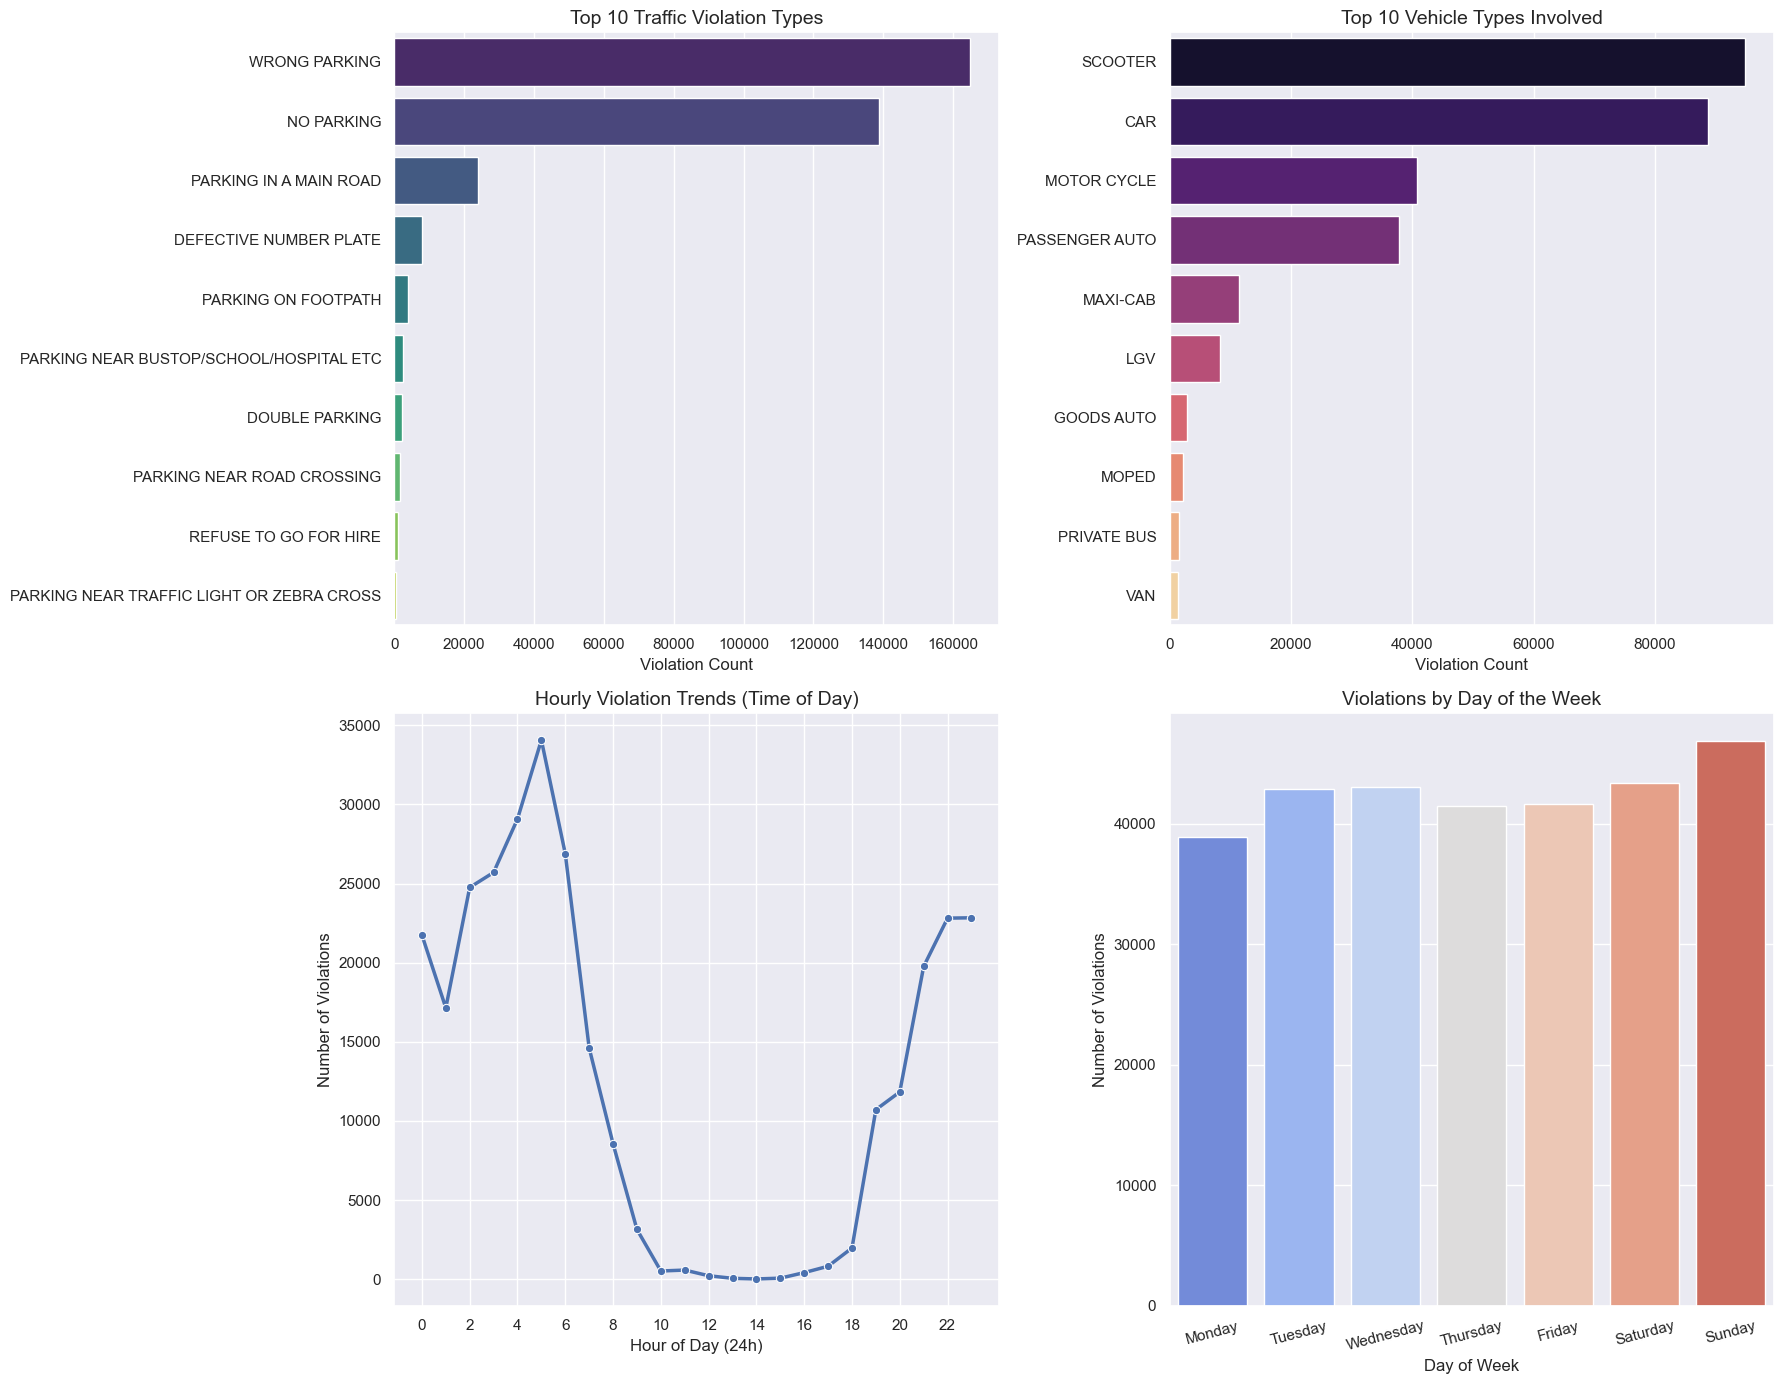

In [32]:
# Set up a grid of subplots to display visualizations inline
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Top Traffic Violations
violation_list = []
for val in df['violation_type']:
    if pd.isna(val) or val == 'NULL':
        continue
    try:
        items = json.loads(val.replace("'", '"'))
        violation_list.extend(items)
    except:
        violation_list.append(str(val))

violation_df = pd.Series(violation_list).value_counts().head(10).reset_index()
violation_df.columns = ['Violation', 'Count']
sns.barplot(x='Count', y='Violation', data=violation_df, hue='Violation', palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Traffic Violation Types', fontsize=14)
axes[0, 0].set_xlabel('Violation Count', fontsize=12)
axes[0, 0].set_ylabel('', fontsize=12)

# 2. Top Vehicle Types Involved
vehicle_df = df['vehicle_type'].value_counts().head(10).reset_index()
vehicle_df.columns = ['Vehicle Type', 'Count']
sns.barplot(x='Count', y='Vehicle Type', data=vehicle_df, hue='Vehicle Type', palette='magma', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Vehicle Types Involved', fontsize=14)
axes[0, 1].set_xlabel('Violation Count', fontsize=12)
axes[0, 1].set_ylabel('', fontsize=12)

# 3. Hourly trends (Time of Day)
hourly_counts = df['hour'].value_counts().sort_index()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', color='b', linewidth=2.5, ax=axes[1, 0])
axes[1, 0].set_title('Hourly Violation Trends (Time of Day)', fontsize=14)
axes[1, 0].set_xlabel('Hour of Day (24h)', fontsize=12)
axes[1, 0].set_ylabel('Number of Violations', fontsize=12)
axes[1, 0].set_xticks(range(0, 24, 2))

# 4. Weekly trends (Day of Week)
daily_counts = df['day_of_week'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
sns.barplot(x=daily_counts.index, y=daily_counts.values, hue=daily_counts.index, palette='coolwarm', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Violations by Day of the Week', fontsize=14)
axes[1, 1].set_xlabel('Day of Week', fontsize=12)
axes[1, 1].set_ylabel('Number of Violations', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Step 8: Create Folium Interactive Map

In [33]:
print("Generating interactive spatial visualization...")
map_center = [df_parking['latitude'].median(), df_parking['longitude'].median()]
m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

# 1. Add HeatMap layer of all parking violations, weighted by individual PCI scores
# Sample 50k points for performance if dataset is large
heat_sample = df_parking[['latitude', 'longitude', 'pci']].sample(n=min(50000, len(df_parking)), random_state=42).values.tolist()
HeatMap(heat_sample, radius=15, blur=10, max_zoom=13).add_to(m)

# 2. Add marker overlays (using folium.Circle for a scaling 100-meter ground radius)
for idx, row in cluster_summary.head(50).iterrows():
    priority = row['priority']
    color = 'red' if 'High' in priority else ('orange' if 'Medium' in priority else 'blue')
    
    popup_html = f"""
    <div style='font-family: Arial, sans-serif; font-size: 12px; width: 250px;'>
        <h4 style='margin: 0 0 5px 0; color: {color};'>Hotspot #{idx+1}</h4>
        <b>Police Jurisdiction:</b> {row['police_station']}<br>
        <b>Total Violations:</b> {row['violation_count']:,}<br>
        <b>Congestion Impact (PCI):</b> {row['total_pci']:.1f}<br>
        <b>Enforcement Priority:</b> <span style='color: {color}; font-weight: bold;'>{priority}</span><br>
        <b>Dominant Vehicle:</b> {row['dominant_vehicle']}<br>
        <b>Main Violation:</b> {row['primary_violation']}<br>
    </div>
    """
    
    folium.Circle(
        location=[row['center_lat'], row['center_lon']],
        radius=100,  # 100 meters ground radius
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.4,  # opacity set to 0.4 so underlying streets/roads are visible
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(m)

# Save interactive map
map_filename = 'parking_hotspots_map.html'
m.save(map_filename)
print(f"Map successfully saved locally to: {map_filename}")

Generating interactive spatial visualization...
Map successfully saved locally to: parking_hotspots_map.html


## Step 9: Station-Level Enforcement Priority Index

In [34]:
print("Aggregating data by police station to create patrol resource dispatch priority list...")
station_priority = cluster_summary.groupby('police_station').agg(
    hotspot_count=('cluster', 'count'),
    cumulative_pci=('total_pci', 'sum'),
    total_violations=('violation_count', 'sum')
).sort_values(by='cumulative_pci', ascending=False).reset_index()

# Save priority dataframe to CSV
station_csv = 'police_patrol_priority.csv'
station_priority.to_csv(station_csv, index=False)

print(f"Resource dispatch priority list saved locally as '{station_csv}':")
station_priority.head(15)

Aggregating data by police station to create patrol resource dispatch priority list...
Resource dispatch priority list saved locally as 'police_patrol_priority.csv':


,police_station,hotspot_count,cumulative_pci,total_violations
0,Upparpet,1,164709.450,51373
1,Shivajinagar,3,56019.350,22827
2,Malleshwaram,4,41313.950,18064
3,Rajajinagar,11,40549.775,14291
4,HAL Old Airport,8,31079.300,16963
5,Vijayanagara,4,22826.500,11501
6,Mahadevapura,7,14282.900,5715
7,Chikkajala,5,14279.650,5270
8,K.R. Pura,4,12586.700,4843
9,Kodigehalli,9,11672.100,7771
